# Natural Language Processing. Assignment 2. BERT Probing.

Rail Sabirov, B23-DS-01, rai.sabirov@innopolis.university

# Note

Running all notebook will take: 1h 54 min
I runned this in kaggle.

## Assignment task

The property we're asking you to probe in BERT is understanding of **negation**, or the words like *not*, *doesn't*, etc. The proposed pipeline is the following:

### 1. Dataset Loading (5 points)

Take [MNLI dataset](https://cims.nyu.edu/~sbowman/multinli/) with sentence pairs annotated with textual entailment information. For some pairs, the hypothesis sentence is the logical entailment of the premise sentence (labeled entailment); in other pairs they are contradictory or neutral. Take only entailment and contradiction labeled pairs.

In [2]:
!pip install datasets transformers torch spacy pyinflect -q
!python -m spacy download en_core_web_sm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 703.5/703.5 kB 10.7 MB/s eta 0:00:00 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 60.8 MB/s eta 0:00:0000:010:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:
from datasets import load_dataset
dataset = load_dataset("multi_nli")
print(dataset)
print("Train split columns:", dataset["train"].column_names)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/214M [00:00<?, ?B/s]

data/validation_matched-00000-of-00001.p(…):   0%|          | 0.00/4.94M [00:00<?, ?B/s]

data/validation_mismatched-00000-of-0000(…):   0%|          | 0.00/5.10M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/392702 [00:00<?, ? examples/s]

Generating validation_matched split:   0%|          | 0/9815 [00:00<?, ? examples/s]

Generating validation_mismatched split:   0%|          | 0/9832 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['promptID', 'pairID', 'premise', 'premise_binary_parse', 'premise_parse', 'hypothesis', 'hypothesis_binary_parse', 'hypothesis_parse', 'genre', 'label'],
        num_rows: 392702
    })
    validation_matched: Dataset({
        features: ['promptID', 'pairID', 'premise', 'premise_binary_parse', 'premise_parse', 'hypothesis', 'hypothesis_binary_parse', 'hypothesis_parse', 'genre', 'label'],
        num_rows: 9815
    })
    validation_mismatched: Dataset({
        features: ['promptID', 'pairID', 'premise', 'premise_binary_parse', 'premise_parse', 'hypothesis', 'hypothesis_binary_parse', 'hypothesis_parse', 'genre', 'label'],
        num_rows: 9832
    })
})
Train split columns: ['promptID', 'pairID', 'premise', 'premise_binary_parse', 'premise_parse', 'hypothesis', 'hypothesis_binary_parse', 'hypothesis_parse', 'genre', 'label']


In [4]:
train = dataset["train"]
val = dataset["validation_matched"]

train_filtered = train.filter(lambda x: x["label"] != 1)
val_filtered = val.filter(lambda x: x["label"] != 1)

print("Filtered train size:", len(train_filtered))
print("- entailment:", sum(1 for x in train_filtered if x["label"] == 0))
print("- contradiction:", sum(1 for x in train_filtered if x["label"] == 2))
print("Filtered validation size:", len(val_filtered))
print("- entailment:", sum(1 for x in val_filtered if x["label"] == 0))
print("- contradiction:", sum(1 for x in val_filtered if x["label"] == 2))

Filter:   0%|          | 0/392702 [00:00<?, ? examples/s]

Filter:   0%|          | 0/9815 [00:00<?, ? examples/s]

Filtered train size: 261802
- entailment: 130899
- contradiction: 130903
Filtered validation size: 6692
- entailment: 3479
- contradiction: 3213


In [5]:
entailment_example = next(x for x in train_filtered if x["label"] == 0)
contradiction_example = next(x for x in train_filtered if x["label"] == 2)
print("Entailment example:")
print("Premise:", entailment_example["premise"])
print("Hypothesis:", entailment_example["hypothesis"])
print("Contradiction example:")
print("Premise:", contradiction_example["premise"])
print("Hypothesis:", contradiction_example["hypothesis"])

Entailment example:
Premise: you know during the season and i guess at at your level uh you lose them to the next level if if they decide to recall the the parent team the Braves decide to call to recall a guy from triple A then a double A guy goes up to replace him and a single A guy goes up to replace him
Hypothesis: You lose the things to the following level if the people recall.
Contradiction example:
Premise: Gays and lesbians.
Hypothesis: Heterosexuals.


In [6]:
# 0 - entailment, 1 - contradiction
def normalize_label(label):
    return 0 if label == 0 else 1

train_filtered = train_filtered.map(lambda x: {"label": normalize_label(x["label"])})
val_filtered = val_filtered.map(lambda x: {"label": normalize_label(x["label"])})
print("Normalized train labels:", set(train_filtered["label"]))
print("Normalized validation labels:", set(val_filtered["label"]))

Map:   0%|          | 0/261802 [00:00<?, ? examples/s]

Map:   0%|          | 0/6692 [00:00<?, ? examples/s]

Normalized train labels: {0, 1}
Normalized validation labels: {0, 1}


In [7]:
data_train = [
    {
        "premise": x["premise"],
        "hypothesis": x["hypothesis"],
        "label": x["label"], # 0=entailment, 1=contradiction
        "genre": x["genre"]
    }
    for x in train_filtered
]

data_val = [
    {
        "premise": x["premise"],
        "hypothesis": x["hypothesis"],
        "label": x["label"], # 0=entailment, 1=contradiction
        "genre": x["genre"]
    }
    for x in val_filtered 
]

### 2. Dataset Preparation (25 points)

Parse the hypothesis sentences in the pairs to get the **main** verb. Create a negated version of the verb. Note that negation doesn't mean antonyms. Construct a new sentence, swapping the corresponding entailment/contradictory labels. Add the new pair to the dataset marked as "negated." If the original main verb contained the negation prefix (didn't, hasn't, etc.), label it as negation, and in the new sentence just remove the prefix. Thus, for every original cartage of premise, hypothesis, and logic label $(p, h, l)$ you should get the opposite version $(p, h`, l)$.

In [8]:
import spacy
import pyinflect
from copy import deepcopy
from tqdm.auto import tqdm

nlp = spacy.load("en_core_web_sm")

In [9]:
def prepare_dataset(data, max_samples=None):
    """
    For each `item` makes:
    - original (negated=False)
    - modified hypothesis (negated=True), with inverted label (0=entailment -> 1=contradiction and vice versa)
    """
    result = []
    skipped_count = 0
    if max_samples:
        samples = data[:max_samples]
    else:
        samples = data

    for item in tqdm(samples, "prepare_data"):
        hypothesis = item['hypothesis']
        label = item['label']
        md_hypothesis, processed = negate_hypothesis(hypothesis)
        if not processed:
            skipped_count += 1
            continue

        result.append({
            "premise": item['premise'],
            "hypothesis": hypothesis,
            "label": label,
            "is_negated": False,
            "genre": item['genre']
        })

        result.append({
            "premise": item["premise"],
            "hypothesis": md_hypothesis,
            "label": 1 - label,
            "is_negated": True,
            "genre": item['genre']
        })

    print(f"{len(result)} overall, {len(result) // 2} pairs, skipped {skipped_count}")
    return result
    

In [10]:
def negate_hypothesis(sent):
    """
    Negates main verbe of the sentence.
    
    Returns (modified_sentence, True) if processed, or (None, False) if
    the sentence cannot be handled (no verbal ROOT, exotic verb form, etc.).

    Steps
    - Find the ROOT token; skip if it is not a VERB / AUX.
    - If a 'neg' dependent exists -> removes it.
    - Otherwise -> inserts negation (add "not" after aux, or inject do-support for lexical verbs).
    """

    doc = nlp(sent)
    root = next((tok for tok in doc if tok.dep_ == "ROOT"), None)
    
    if root is None or root.pos_ not in ("VERB", "AUX"):
        return None, False

    neg_tok = next((child for child in root.children if child.dep_ == "neg"), None)
    aux_tok = next((child for child in root.children if child.dep_ in ("aux", "auxpass")), None)
    tok_list = [[tok.text, tok.whitespace_] for tok in doc]

    if neg_tok is not None:
        return remove_negation(root, neg_tok, aux_tok, tok_list)
    else:
        return add_negation(root, aux_tok, tok_list)

In [ ]:
def reconstruct_sentence(tok_list):
    """
    Reconstructs sentence from list of [text, whitespace] pairs, skipping None tokens.
    """
    result = ""
    for text, ws in tok_list:
        if text is None:
            continue
        result += text + ws
    return result.strip()

In [ ]:
def remove_negation(root, neg_tok, aux_tok, tok_list):
    """
    Removes negation from a sentence given spacy token indices.
    """
    new_toks = [list(tok) for tok in tok_list]
    new_toks[neg_tok.i][0] = None

    if aux_tok is not None:
        aux_text = aux_tok.text.lower()
        # Fix contracted aux forms: "wo" -> "will", "ca" -> "can", "sha" -> "shall"
        fix_map = {"wo": "will", "ca": "can", "sha": "shall"}
        if aux_text in fix_map:
            new_toks[aux_tok.i][0] = fix_map[aux_text]
        # "does n't VERB" -> VERB(VBZ); "did n't VERB" -> VERB(VBD)
        elif aux_text in ("does", "did"):
            new_toks[aux_tok.i][0] = None  # remove do/did
            target_form = "VBZ" if aux_text == "does" else "VBD"
            inflected = root._.inflect(target_form)
            if inflected is None:
                return None, False
            new_toks[root.i][0] = inflected

    return reconstruct_sentence(new_toks), True

In [ ]:
def add_negation(root, aux_tok, tok_list):
    """
    Adds negation to a sentence.
    """
    new_toks = [list(tok) for tok in tok_list]
    root_tag = root.tag_

    if aux_tok is not None:
        # Insert "not" after the auxiliary verb
        aux_i = aux_tok.i
        aux_ws = new_toks[aux_i][1]
        new_toks[aux_i][1] = " "
        new_toks.insert(aux_i + 1, ["not", aux_ws])
        return reconstruct_sentence(new_toks), True

    if root.pos_ == "AUX":
        # Copula/aux as ROOT with no aux child ("He is ready.")
        root_ws = new_toks[root.i][1]
        new_toks[root.i][1] = " "
        new_toks.insert(root.i + 1, ["not", root_ws])
        return reconstruct_sentence(new_toks), True

    # Lexical verb — requires do-support
    if root_tag == "VBZ": # runs -> does not run
        base = root._.inflect("VB")
        if base is None:
            return None, False
        new_toks[root.i][0] = base
        new_toks.insert(root.i, ["not", " "])
        new_toks.insert(root.i, ["does", " "])
        return reconstruct_sentence(new_toks), True

    elif root_tag == "VBD": # ran -> did not run
        base = root._.inflect("VB")
        if base is None:
            return None, False
        new_toks[root.i][0] = base
        new_toks.insert(root.i, ["not", " "])
        new_toks.insert(root.i, ["did", " "])
        return reconstruct_sentence(new_toks), True

    elif root_tag in ("VBP", "VB"): # run -> do not run
        base = root._.inflect("VB") or root.text
        new_toks[root.i][0] = base
        new_toks.insert(root.i, ["not", " "])
        new_toks.insert(root.i, ["do", " "])
        return reconstruct_sentence(new_toks), True

    return None, False

In [14]:
print("Train data preparation")
prepared_train = prepare_dataset(data_train)

Train data preparation


prepare_data:   0%|          | 0/261802 [00:00<?, ?it/s]

500914 overall, 250457 pairs, skipped 11345


In [15]:
print("Validation data preparation")
prepared_val = prepare_dataset(data_val)

Validation data preparation


prepare_data:   0%|          | 0/6692 [00:00<?, ?it/s]

12804 overall, 6402 pairs, skipped 290


In [16]:
print("Original:", prepared_train[0]["hypothesis"], ", label:", prepared_train[0]["label"], ", is_negated:", prepared_train[0]["is_negated"])
print("Modified:", prepared_train[1]["hypothesis"], ", label:", prepared_train[1]["label"], ", is_negated:", prepared_train[1]["is_negated"])
print("Premise:", prepared_train[0]["premise"])

Original: You lose the things to the following level if the people recall. , label: 0 , is_negated: False
Modified: You do not lose the things to the following level if the people recall. , label: 1 , is_negated: True
Premise: you know during the season and i guess at at your level uh you lose them to the next level if if they decide to recall the the parent team the Braves decide to call to recall a guy from triple A then a double A guy goes up to replace him and a single A guy goes up to replace him


### 3. Hooking the Representation (20 points)

Pass the dataset through the original BERT on the MNLI classification. Save the representation of the hypothesis for which the negation led to a prediction swap in BERT.

In [17]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification

In [18]:
MODEL_NAME = "textattack/bert-base-uncased-MNLI"   # BERT fine-tuned on MNLI
LAYERS = [6, 11] # layers to probe
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [19]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model.eval().to(device)
print("Model id2label:", model.config.id2label)

config.json:   0%|          | 0.00/630 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Model id2label: {0: 'LABEL_0', 1: 'LABEL_1', 2: 'LABEL_2'}


In [20]:
activations_cache: dict[int, torch.Tensor] = {}

def make_hook(layer_idx: int):
    def hook(module, input, output):
        hidden_states = output[0] if isinstance(output, tuple) else output
        activations_cache[layer_idx] = hidden_states.detach().cpu()
    return hook

hooks = []
for layer_idx in LAYERS:
    h = model.bert.encoder.layer[layer_idx].register_forward_hook(make_hook(layer_idx))
    hooks.append(h)

In [ ]:
def hypothesis_mean_pool(hidden: torch.Tensor, input_ids: torch.Tensor, token_type_ids: torch.Tensor) -> np.ndarray:
    """
    Mean pooling over hypothesis tokens (token_type_id == 1) excluding [SEP] tokens.
    Returns numpy vector of shape (hidden_size,).
    """
    sep_id  = tokenizer.sep_token_id
    # mask: type==1 AND not [SEP]
    mask = (token_type_ids == 1) & (input_ids != sep_id)   # (seq_len,)
    mask = mask.bool()
    if mask.sum() == 0:
        return None
    vecs = hidden[0][mask] # (n_hyp_tokens, hidden_size)
    return vecs.mean(dim=0).numpy()

In [22]:
def extract_representations(prepared_data, batch_size=32):
    """
    Iterates over paired records.
    Steps:
      - runs BERT on (premise, hypothesis_orig) and (premise, hypothesis_negated)
      - keeps the pair only if BERT prediction swaps between the two
      - saves mean-pooled hypothesis representations from each hooked layer

    Returns:
    [
      {
        "layer": int,
        "vec_orig": np.ndarray, # representation of original hypothesis
        "vec_neg": np.ndarray, # representation of negated hypothesis
        "label_orig": int, # 0=entailment, 1=contradiction
        "premise": str,
        "hyp_orig": str,
        "hyp_neg": str,
      }
    ]
    """
    records = []
    total_pairs = len(prepared_data) // 2
    swapped = 0

    for pair_idx in tqdm(range(total_pairs), desc="Extracting representations:"):
        orig = prepared_data[pair_idx * 2]
        neg  = prepared_data[pair_idx * 2 + 1]
        premise   = orig["premise"]
        hyp_orig  = orig["hypothesis"]
        hyp_neg   = neg["hypothesis"]
        reps = {} # layer_idx - > {"orig": vec, "neg": vec}

        for hyp_key, hyp_text in [("orig", hyp_orig), ("neg", hyp_neg)]:
            enc = tokenizer(premise, hyp_text, return_tensors="pt", truncation=True,
                            max_length=128, padding=False).to(device)

            activations_cache.clear()
            with torch.no_grad():
                out = model(**enc)

            pred = out.logits.argmax(dim=-1).item()

            # pooling per layer
            ids = enc["input_ids"].cpu()[0]
            tt_ids = enc["token_type_ids"].cpu()[0]

            for layer_idx in LAYERS:
                hidden = activations_cache[layer_idx]   # (1, seq, hidden)
                vec    = hypothesis_mean_pool(hidden, ids, tt_ids)
                if layer_idx not in reps:
                    reps[layer_idx] = {}
                reps[layer_idx][hyp_key]  = vec
                reps[layer_idx][f"pred_{hyp_key}"] = pred

        # Keep only swap pairs
        for layer_idx in LAYERS:
            p_orig = reps[layer_idx]["pred_orig"]
            p_neg  = reps[layer_idx]["pred_neg"]
            if p_orig != p_neg and reps[layer_idx]["orig"] is not None and reps[layer_idx]["neg"] is not None:
                records.append({
                    "layer": layer_idx,
                    "vec_orig": reps[layer_idx]["orig"],
                    "vec_neg": reps[layer_idx]["neg"],
                    "label_orig": orig["label"],
                    "premise": premise,
                    "hyp_orig": hyp_orig,
                    "hyp_neg": hyp_neg,
                })
                if layer_idx == LAYERS[0]:
                    swapped += 1

    print(f"Total pairs: {total_pairs}, swap pairs: {swapped} ({swapped/total_pairs*100}%)")
    print(f"Saved records (per layer): { {layer_idx: sum(1 for r in records if r['layer']==layer_idx) for layer_idx in LAYERS} }")
    return records

In [23]:
print("Extract train")
train_reps = extract_representations(prepared_train)

Extract train


Extracting representations::   0%|          | 0/250457 [00:00<?, ?it/s]

Total pairs: 250457, swap pairs: 175295 (69.99005817365855%)
Saved records (per layer): {6: 175295, 11: 175295}


In [24]:
print("Extract val")
val_reps = extract_representations(prepared_val)

Extract val


Extracting representations::   0%|          | 0/6402 [00:00<?, ?it/s]

Total pairs: 6402, swap pairs: 4389 (68.55670103092784%)
Saved records (per layer): {6: 4389, 11: 4389}


### 4. Probe Training (25 points)

For the saved pairs, take the representations of $(p, h)$ and $(p, h')$, and train a probe classifier to detect which of $h'$ or $h$ (of the same pair) contains negation.
When passing pairs to the probe, make sure that you're shuffling negated and
original hypotheses to prevent bias, such as negated representations always being
second. Even getting the high accuracy, you can lose quite a lot of points on this
stage if the training procedure is biased (example in the previous sentence).

In [25]:
import torch.nn as nn
import random
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score

In [26]:
def seed_all(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    print("Seeded")

seed_all()

Seeded


In [27]:
class NegationProbeDataset(Dataset):
    """
    Every element is a pair (vec_orig, vec_neg).
    To prevent positional bias, randomly shuffles the order.
    """
    def __init__(self, records, layer_idx):
        self.items = [r for r in records if r["layer"] == layer_idx]

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        r = self.items[idx]
        v_orig = torch.tensor(r["vec_orig"], dtype=torch.float32)
        v_neg  = torch.tensor(r["vec_neg"],  dtype=torch.float32)

        if random.random() < 0.5:
            # negated is first -> label = 1
            x = torch.cat([v_neg, v_orig], dim=0)
            y = 1
        else:
            # negated is second -> label = 0
            x = torch.cat([v_orig, v_neg], dim=0)
            y = 0

        return x, torch.tensor(y, dtype=torch.long)

In [28]:
class NegationProbe(nn.Module):
    """
    Simple 1-layer MLP.
    Input: concat of two vectors  → 768*2 = 1536 dim.
    """
    def __init__(self, input_dim=768*2, hidden_dim=256, dropout=0.2):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 2),
        )

    def forward(self, x):
        return self.mlp(x)

In [29]:
def train_probe(model, train_loader, val_loader, epochs=10, lr=1e-3, device=device, patience=3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

    best_val_acc  = 0.0
    best_state    = None
    no_improve    = 0
    history       = []

    model.to(device)

    for epoch in range(1, epochs + 1):
        model.train()
        all_preds, all_labels = [], []
        total_loss = 0.0

        for x, y in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs} [train]", leave=False):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss   = criterion(logits, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * len(y)
            all_preds.extend(logits.argmax(dim=1).cpu().tolist())
            all_labels.extend(y.cpu().tolist())

        train_acc  = accuracy_score(all_labels, all_preds)
        train_loss = total_loss / len(all_labels)

        val_acc, val_loss = eval_probe(model, val_loader, criterion, device)
        scheduler.step(val_acc)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss":   val_loss,
            "val_acc":   val_acc,
        })
        print(f"Epoch {epoch}, train loss {train_loss:.4f} acc {train_acc:.4f}, val loss {val_loss:.4f} acc {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve   = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at epoch {epoch}.")
                break

    model.load_state_dict(best_state)
    print(f"Best val accuracy: {best_val_acc:.4f}")
    return model, history


@torch.no_grad()
def eval_probe(model, loader, criterion, device=device):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss   = criterion(logits, y)
        total_loss += loss.item() * len(y)
        all_preds.extend(logits.argmax(dim=1).cpu().tolist())
        all_labels.extend(y.cpu().tolist())

    acc  = accuracy_score(all_labels, all_preds)
    loss = total_loss / len(all_labels)
    return acc, loss

In [30]:
BATCH_SIZE = 64
EPOCHS = 15
HIDDEN_DIM = 256
DROPOUT = 0.2

probe_results = {}   # layer -> {"model", "history", "val_acc"}

for layer_idx in LAYERS:
    print(f"Training probe for LAYER {layer_idx}")

    train_ds = NegationProbeDataset(train_reps, layer_idx)
    val_ds = NegationProbeDataset(val_reps, layer_idx)

    print(f"Train pairs: {len(train_ds)}, Val pairs: {len(val_ds)}")

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    probe = NegationProbe(input_dim=768*2, hidden_dim=HIDDEN_DIM, dropout=DROPOUT)
    probe, history = train_probe(probe, train_loader, val_loader, epochs=EPOCHS, lr=1e-3, device=device, patience=3)

    final_val_acc, _ = eval_probe(probe, val_loader, nn.CrossEntropyLoss(), device)
    probe_results[layer_idx] = {
        "model":   probe,
        "history": history,
        "val_acc": final_val_acc,
    }


print(f"{'Layer':<10} {'Val Accuracy':>14}  {'vs Baseline':>12}")
for layer_idx, res in probe_results.items():
    delta = res["val_acc"] - 0.5
    print(f"Layer {layer_idx:<5} {res['val_acc']:>14.4f}  {delta:>+12.4f}")

Training probe for LAYER 6
Train pairs: 175295, Val pairs: 4389


Epoch 1/15 [train]:   0%|          | 0/2738 [00:00<?, ?it/s]

Epoch 1, train loss 0.2204 acc 0.9215, val loss 0.1927 acc 0.9346


Epoch 2/15 [train]:   0%|          | 0/2738 [00:00<?, ?it/s]

Epoch 2, train loss 0.1998 acc 0.9301, val loss 0.2040 acc 0.9319


...

Epoch 12, train loss 0.1877 acc 0.9323, val loss 0.2019 acc 0.9266


Epoch 13/15 [train]:   0%|          | 0/2738 [00:00<?, ?it/s]

Epoch 13, train loss 0.1870 acc 0.9324, val loss 0.1892 acc 0.9310


Epoch 14/15 [train]:   0%|          | 0/2738 [00:00<?, ?it/s]

Epoch 14, train loss 0.1868 acc 0.9328, val loss 0.1965 acc 0.9275
Early stopping at epoch 14.
Best val accuracy: 0.9337
Layer        Val Accuracy   vs Baseline
Layer 6             0.9367       +0.4367
Layer 11            0.9319       +0.4319


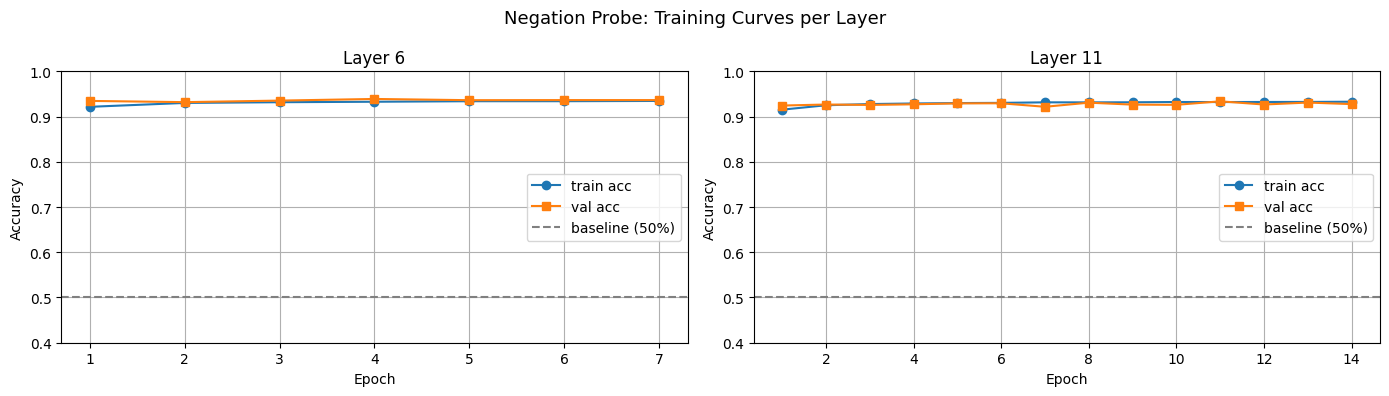

In [31]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(LAYERS), figsize=(7 * len(LAYERS), 4))

for ax, layer_idx in zip(axes, LAYERS):
    history = probe_results[layer_idx]["history"]
    epochs  = [h["epoch"] for h in history]
    t_acc   = [h["train_acc"] for h in history]
    v_acc   = [h["val_acc"] for h in history]

    ax.plot(epochs, t_acc, label="train acc", marker="o")
    ax.plot(epochs, v_acc, label="val acc",   marker="s")
    ax.axhline(0.5, color="gray", linestyle="--", label="baseline (50%)")
    ax.set_title(f"Layer {layer_idx}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0.4, 1.0)
    ax.legend()
    ax.grid(True)

plt.suptitle("Negation Probe: Training Curves per Layer", fontsize=13)
plt.tight_layout()
plt.show()

### 5. Solution Analysis (25 points)

Analyze how well the proposed probe detects the negation understanding by BERT. Add the text as a markdown cell(s) at the very end of the notebook. Describe the ways you've used to **optimize the complexity of the probe**. Justify your decisions. And finally: **does BERT encode negation features?** We're not sure, though, so there are no wrong answers and low probe accuracies, but wrong and poorly proofed probe designs.

In this experiment, I tested whether BERT representations contain information related to negation in the MNLI task. To do this, I first created negated versions of the original hypotheses, flipped the label between entailment and contradiction, and then passed both the original and negated sentence pairs through a BERT model fine-tuned on MNLI. After that, I trained a probe to distinguish which hypothesis in a pair was the negated one.

The probe achieved high validation accuracy on both selected layers. This means that the hidden representations of BERT contain information that makes negated and non-negated hypotheses separable. So, based on these results, I can say that BERT does encode features that are strongly related to negation.

### However

High probe accuracy does not automatically prove that BERT fully understands negation in a deep logical or semantic sense. The probe may detect relatively surface-level cues, for example the presence of explicit negation markers such as not, do not, did not, and similar constructions. BERT representations may separate them well even if the model does not always perform full logical reasoning over negation scope or sentence meaning. So the result shows that negation-related information is encoded, but it does not prove complete semantic understanding.

I also tried to keep the probe reasonably simple, because probe complexity affects interpretation. If the probe is too powerful, it may learn the task by itself instead of revealing what is already present in the representations. For this reason, I used a relatively small feed-forward classifier with one hidden layer, dropout, weight decay, and early stopping, instead of a deeper network. I also used only aggregated hypothesis representations from individual BERT layers, rather than more complicated architectures. This keeps the probe limited enough to make the result more meaningful, although it is still more expressive than a purely linear probe. Because of that, the conclusions should remain somewhat cautious.

Mean-pooled token representations was used of the hypothesis instead of only the [CLS] token. Negation is usually expressed locally inside the hypothesis tokens. I also tested two different layers of BERT, since information can be distributed differently across the network. The results were strong for both layers, which suggests that negation-related features are not restricted to only one specific level of representation.

There are also several limitations in the data construction step. The negation generation procedure is rule-based and depends on the main verb detected by spaCy. This works for many simple hypotheses, but it may fail for more complex syntax, multi-clause sentences, unusual verb structures, or cases where negation scope is ambiguous. Because of this, the transformed dataset is only an approximation of true semantic negation. In addition, by selecting only cases where the model prediction changes after negation, the experiment focuses on examples where negation has a visible effect on the classifier, which may bias the final sample toward easier or cleaner cases.

Overall, my conclusion is that BERT does encode negation-related features in its hidden representations, because the probe can recover this information with high accuracy from multiple layers. At the same time, I would not claim that this alone proves full understanding of negation as a logical phenomenon. A more careful interpretation is that BERT representations contain strong and usable signals correlated with negation, but some part of this signal may come from explicit lexical markers rather than deeper reasoning. So the experiment supports the claim that negation is represented in BERT, but only with the usual limitations of probe-based analysis.